# Atelier TensorFlow / Keras — Prédiction de la consommation énergétique

**Contexte.** Des bâtiments sont équipés de capteurs. Pour chaque observation on connaît la température, l'humidité et le nombre d'occupants. On veut construire un **réseau de neurones** qui prédit la **consommation énergétique** à partir de ces trois caractéristiques.

C'est un problème de **régression** : la cible (consommation) est un nombre continu.

## Partie 0 — Mise en place de l'environnement

On importe les trois librairies demandées :
- **numpy** : calcul numérique et génération des données aléatoires,
- **tensorflow / keras** : construction et entraînement du réseau de neurones,
- **matplotlib** : visualisation.

> Si TensorFlow n'est pas installé : `pip install tensorflow`

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.21.0


On **fixe les graines aléatoires** (numpy et TensorFlow). Cela rend l'exécution **reproductible** : on obtiendra les mêmes données générées et le même entraînement à chaque relance.

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## Partie 1 — Génération du dataset

On simule **1000 observations**. Pour chaque variable on choisit une loi de probabilité adaptée :

| Variable | Loi | Paramètres |
|---|---|---|
| `temperature` | Normale (gaussienne) | moyenne = 25 °C, écart-type = 4 °C |
| `humidite` | Uniforme | entre 30 % et 80 % |
| `occupants` | Entiers uniformes | de 1 à 49 inclus |

- **loi normale** : les valeurs se concentrent autour de la moyenne (25) et deviennent rares en s'en éloignant.
- **loi uniforme** : toutes les valeurs entre 30 et 80 ont la même chance de sortir.

In [3]:
n = 1000

temperature = np.random.normal(loc=25, scale=4, size=n)      # moyenne 25, ecart-type 4
humidite    = np.random.uniform(low=30, high=80, size=n)     # uniforme entre 30 et 80
occupants   = np.random.randint(low=1, high=50, size=n)      # entiers 1..49 (high exclu)

print("temperature :", temperature[:5])
print("humidite    :", humidite[:5])
print("occupants   :", occupants[:5])

temperature : [26.98685661 24.4469428  27.59075415 31.09211943 24.0633865 ]
humidite    : [38.37412911 35.22839202 61.82151248 65.32378632 31.57930724]
occupants   : [ 8 43 20 33 26]


### Construction de la cible `consommation`

On applique la formule "physique" donnée par l'énoncé :

$$ \text{consommation} = 50 + 5\times\text{temp} + 1.5\times\text{humidite} + 4\times\text{occupants} + \text{bruit} $$

- **50** = consommation de base (0 °C, 0 % humidité, pièce vide),
- **+5** par degré, **+1.5** par % d'humidité, **+4** par occupant,
- le **bruit** (loi normale de moyenne 0, écart-type 10) simule les imprévus : dans la vraie vie aucune formule n'est parfaite. C'est justement ce que le réseau devra apprendre à approcher **sans** connaître la formule.

In [4]:
bruit = np.random.normal(loc=0, scale=10, size=n)

consommation = 50 + 5*temperature + 1.5*humidite + 4*occupants + bruit

print("consommation :", consommation[:5])

consommation : [281.62608854 406.67868707 348.62841819 433.63621523 318.9414931 ]


### Matrice des caractéristiques `X` et cible `y`

- `X` regroupe les 3 variables explicatives → forme **(1000, 3)**.
- `y` contient la consommation → forme **(1000,)**.

On convertit en **float32** : c'est le format optimisé pour les calculs sur GPU/CPU dans TensorFlow.

In [5]:
X = np.column_stack([temperature, humidite, occupants]).astype("float32")
y = consommation.astype("float32")

print("Forme de X :", X.shape)   # (1000, 3)
print("Forme de y :", y.shape)   # (1000,)
print("\n5 premieres lignes de X :\n", X[:5])

Forme de X : (1000, 3)
Forme de y : (1000,)

5 premieres lignes de X :
 [[26.986856 38.37413   8.      ]
 [24.446943 35.228394 43.      ]
 [27.590754 61.821514 20.      ]
 [31.09212  65.323784 33.      ]
 [24.063387 31.579308 26.      ]]


## Partie 2 — Découpage Train / Test

On sépare les données en deux :
- **train (80 %)** : sert à *entraîner* le modèle,
- **test (20 %)** : sert à *évaluer* le modèle sur des données jamais vues.

`random_state=42` garantit la **reproductibilité** du découpage.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape,  y_test.shape)

Train : (800, 3) (800,)
Test  : (200, 3) (200,)


## Partie 3 — Création du modèle

On empile 3 couches denses (**Sequential** = les couches s'enchaînent l'une après l'autre) :

1. **16 neurones**, activation **ReLU**,
2. **8 neurones**, activation **ReLU**,
3. **1 neurone** (sortie) — pas d'activation : on veut une valeur continue (régression).

- **neurone** : une petite unité qui combine ses entrées et produit une sortie.
- **ReLU** (`Rectified Linear Unit`) : fonction d'activation qui renvoie `max(0, x)`. Elle introduit de la **non-linéarité**, ce qui permet au réseau d'apprendre des relations complexes.
- `input_shape=(3,)` indique que chaque exemple a **3 caractéristiques**.

In [7]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(3,)),   # couche 1
    layers.Dense(8,  activation="relu"),                     # couche 2
    layers.Dense(1)                                          # couche 3 : sortie
])

c:\Users\NGOM PC\Downloads\atelier_tensorflow_iot\atelier_tensorflow_iot\.venv313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Résumé de l'architecture

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Partie 4 — Compilation du modèle

Compiler = préciser **comment le modèle va apprendre** :
- **optimizer = `adam`** : l'algorithme qui ajuste les poids du réseau à chaque étape (Adam est un choix robuste et standard).
- **loss = `mse`** (Mean Squared Error, erreur quadratique moyenne) : la fonction que le modèle cherche à **minimiser**. Elle pénalise fortement les grosses erreurs.
- **metric = `mae`** (Mean Absolute Error, erreur absolue moyenne) : plus lisible pour nous — c'est l'écart moyen, en unités de consommation, entre prédiction et réalité.

In [10]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Partie 5 — Entraînement du modèle

On entraîne avec :
- `validation_split=0.2` : 20 % du train sert de **validation** (pour surveiller le sur-apprentissage),
- `epochs=50` : le modèle voit **50 fois** l'ensemble des données,
- `batch_size=16` : les poids sont mis à jour toutes les **16 observations**.

L'objet `history` mémorise l'évolution de l'erreur au fil des époques.

In [11]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 123921.7500 - mae: 346.4047 - val_loss: 115669.8359 - val_mae: 335.2694
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 109993.0859 - mae: 326.2811 - val_loss: 100628.5000 - val_mae: 312.6548
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 93241.1016 - mae: 300.2661 - val_loss: 82419.4297 - val_mae: 282.8368
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 73350.5391 - mae: 266.0380 - val_loss: 61362.1172 - val_mae: 243.8318
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 51171.7812 - mae: 221.7012 - val_loss: 39066.4922 - val_mae: 194.1818
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29633.0195 - mae: 167.6960 - val_loss: 19749.4062 - val_mae: 137.0994
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13321.2764 - mae: 110.3811 - val_loss: 7475.1963 - val_mae: 81.8867
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4579.0537 - mae: 60.8192 - val_loss: 2336.

### Examiner le contenu de `history`

`history.history` est un dictionnaire contenant l'erreur (`loss`, `mae`) sur le train **et** sur la validation (`val_loss`, `val_mae`), une valeur par époque.

In [12]:
print("Cles disponibles :", list(history.history.keys()))
print("\nloss (train) - 5 premieres epoques :", history.history["loss"][:5])
print("val_loss (validation) - 5 premieres :", history.history["val_loss"][:5])

Cles disponibles : ['loss', 'mae', 'val_loss', 'val_mae']

loss (train) - 5 premieres epoques : [123921.75, 109993.0859375, 93241.1015625, 73350.5390625, 51171.78125]
val_loss (validation) - 5 premieres : [115669.8359375, 100628.5, 82419.4296875, 61362.1171875, 39066.4921875]


### Visualiser l'apprentissage

On trace l'erreur d'entraînement et de validation en fonction des époques.

**Interprétation attendue :** les deux courbes doivent **descendre** puis se stabiliser. Si la courbe de validation remonte alors que celle du train continue de descendre → **sur-apprentissage** (overfitting).

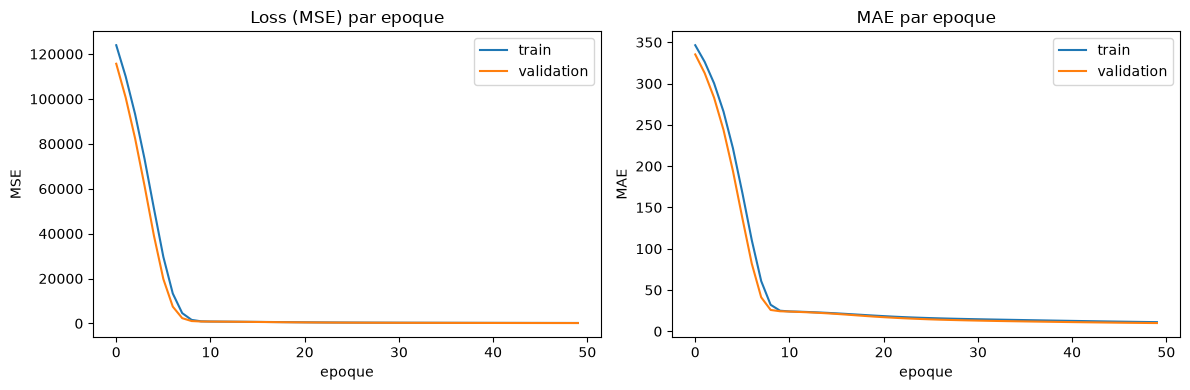

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss (MSE) par epoque")
axes[0].set_xlabel("epoque"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="validation")
axes[1].set_title("MAE par epoque")
axes[1].set_xlabel("epoque"); axes[1].set_ylabel("MAE"); axes[1].legend()

plt.tight_layout()
plt.show()

**Lecture du graphique :** l'erreur chute vite au début (le modèle apprend la tendance générale) puis se stabilise. Les courbes train et validation restent proches → le modèle **généralise bien**, il n'y a pas de sur-apprentissage marqué.